Statistical project to analyze timeseries of stock returns

initial stock analyzed is Apple

In [ ]:
# imports
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels
from scipy.stats

In [71]:
# Choose asset
ticker = "AAPL"

# Download daily data
df = yf.download(ticker, start="2005-01-01", progress=True)


[*********************100%***********************]  1 of 1 completed


In [72]:
df['pct-returns'] = df['Close'].pct_change()
df['log-returns'] = np.log(df['Close']).diff()

In [73]:
# Autocorrelation 
mean_return = np.mean(df['pct-returns'])
def autocorr(ticker_data=df, lag=1):
    ticker_data['pct-returns'] = ticker_data['pct-returns'].dropna()
    mean_return = np.mean(ticker_data['pct-returns'])
    cov_sum = 0
    var_sum = 0
    for t in range(lag, len(ticker_data['pct-returns'])):
        cov_sum += (ticker_data['pct-returns'].iloc[t] - mean_return) * (ticker_data['pct-returns'].iloc[t-lag] - mean_return)
    for t in range(0, len(ticker_data['pct-returns'])):
        var_sum += (ticker_data['pct-returns'].iloc[t] - mean_return) ** 2

    return cov_sum / var_sum

autocorr(df, 10)

np.float64(nan)

In [74]:
df.head()

Price,Close,High,Low,Open,Volume,pct-returns,log-returns
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2005-01-03,0.948179,0.975446,0.937842,0.970502,691992000,NaN,NaN
2005-01-04,0.957917,0.980838,0.943385,0.955670,1096810400,0.010270,0.010217
2005-01-05,0.966307,0.977544,0.959565,0.965707,680433600,0.008759,0.008721
2005-01-06,0.967056,0.972449,0.948778,0.968853,705555200,0.000775,0.000775
2005-01-07,1.037469,1.043162,0.970053,0.973798,2227450400,0.072812,0.070283


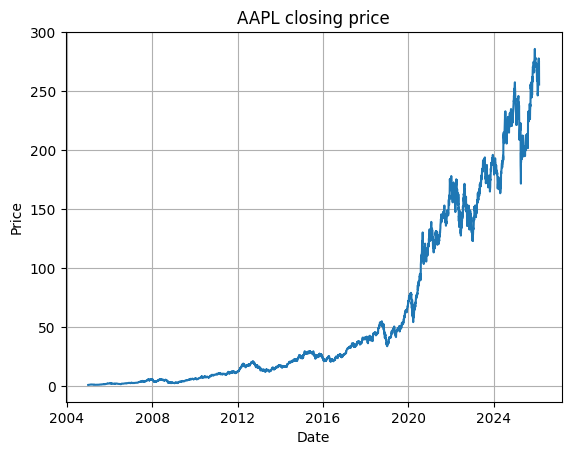

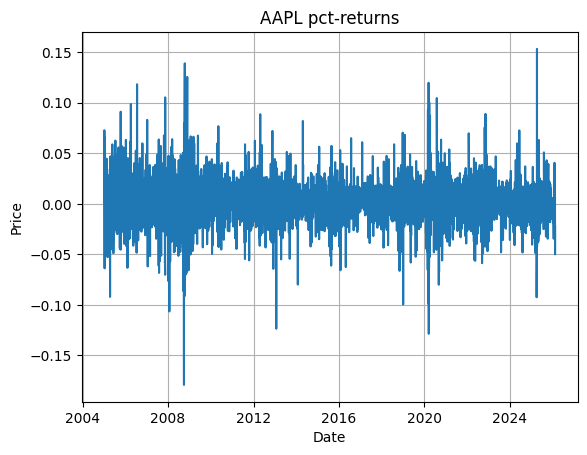

In [75]:
# Plotting closing price
plt.figure()
plt.plot(df.index, df["Close"])
plt.title(f"{ticker} closing price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(df.index, df["pct-returns"])
plt.title(f"{ticker} pct-returns")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

# plt.figure()
# plt.plot(df.index, df["log-returns"])
# plt.title(f"{ticker} log-returns")
# plt.xlabel("Date")
# plt.ylabel("Price")
# plt.grid(True)
# plt.show()


Autocorrelation:
for r --> autocorrelation in mean
for r^2 --> variance
for |r| --> volatility
 

<Figure size 640x480 with 0 Axes>

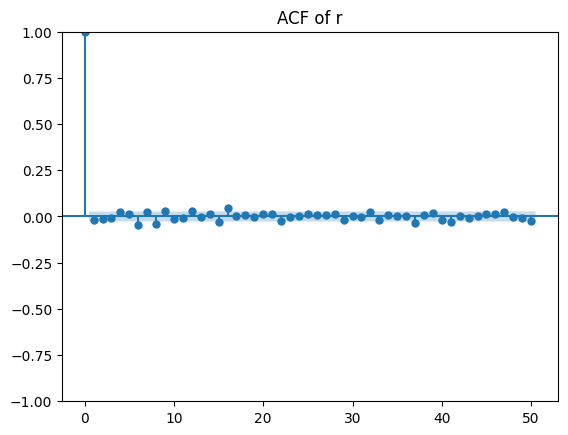

<Figure size 640x480 with 0 Axes>

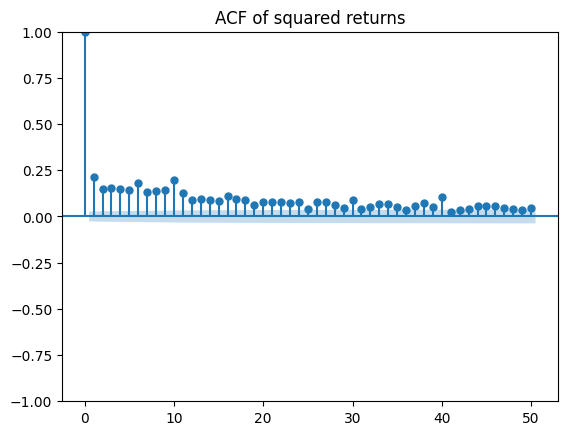

<Figure size 640x480 with 0 Axes>

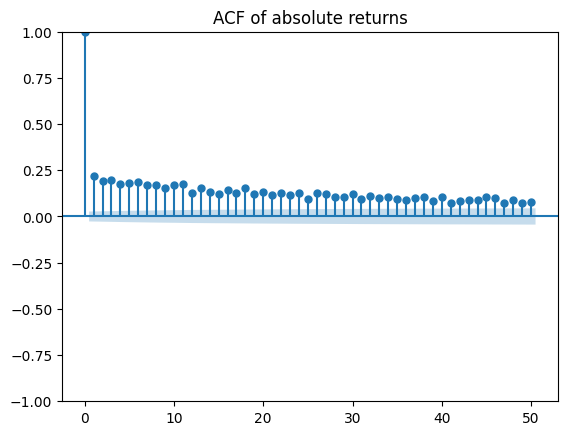

In [84]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

r = df["pct-returns"].dropna()
r_abs = np.abs(df["pct-returns"].dropna())
r_2 = np.pow(df["pct-returns"].dropna(), 2)

plt.figure()
plot_acf(r, lags=50)
plt.title("ACF of r")
plt.show()

plt.figure()
plot_acf(r_2, lags=50)
plt.title("ACF of squared returns")
plt.show()

plt.figure()
plot_acf(r_abs, lags=50)
plt.title("ACF of absolute returns")
plt.show()


Ljung-Box for r^2 showing p-values < 0.05 indicates autocorrelation (volatility clustering).
"The probability of observing this much autocorrelation in squared returns if variance were constant is very small or extremely small."

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

def ljung_box_plot(series, max_lag=50, title="Ljung–Box p-values"):
    """
    Plot Ljung–Box p-values for lags 1..max_lag.
    Interpretation:
      - small p-values (e.g. < 0.05) => reject 'no autocorrelation' up to that lag.
    """
    x = pd.Series(series).dropna().astype(float)

    # returns DataFrame with columns: lb_stat, lb_pvalue
    res = acorr_ljungbox(x, lags=range(1, max_lag + 1), return_df=True)

    plt.figure(figsize=(10, 4))
    plt.plot(res.index, res["lb_pvalue"])
    plt.axhline(0.05, linestyle="--")  # significance line
    plt.title(title)
    plt.xlabel("Lag")
    plt.ylabel("p-value")
    plt.ylim(-0.02, 1.02)
    plt.grid(True)
    plt.show()

    return res

# Example usage (assuming you already have a Series r of returns)
r = df["pct-returns"].dropna()

# # 1) Mean dependence test
# ljung_box_plot(r, max_lag=50, title="Ljung–Box on returns")

# 2) Volatility clustering test
ljung_box_plot(np.pow(r, 2), max_lag=50, title="Ljung–Box on squared returns")

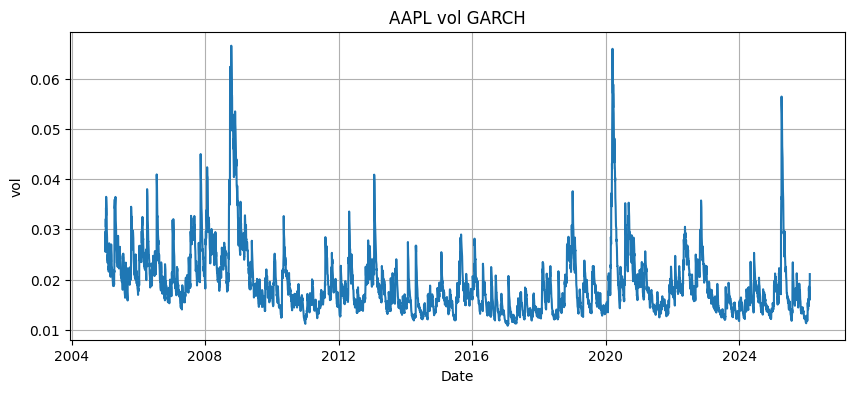

In [106]:
# Calculating volatility to normalize for vol.

from arch import arch_model

r = df["pct-returns"].dropna() * 100  # scaling helps numerics

model = arch_model(r, vol="GARCH", p=1, q=1, mean="Zero")
res = model.fit(disp="off")

# print(res.summary())

sigma = res.conditional_volatility / 100
# print(sigma)

plt.figure(figsize = (10, 4))
plt.plot(sigma)
plt.title(f"{ticker} vol GARCH")
plt.xlabel("Date")
plt.ylabel("vol")
plt.grid(True)
plt.show()



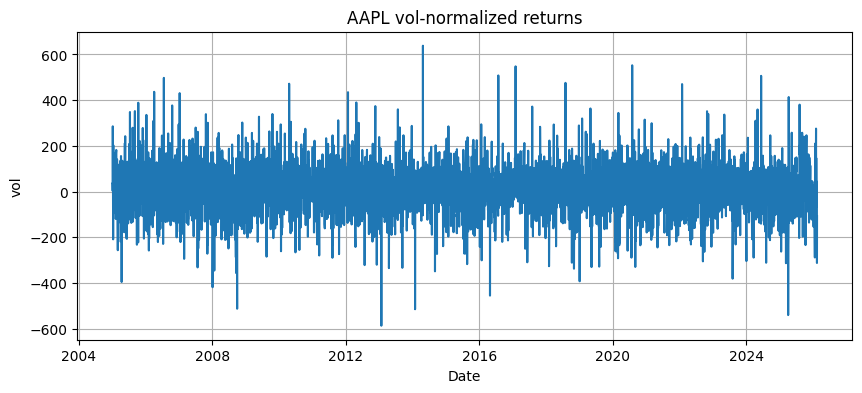

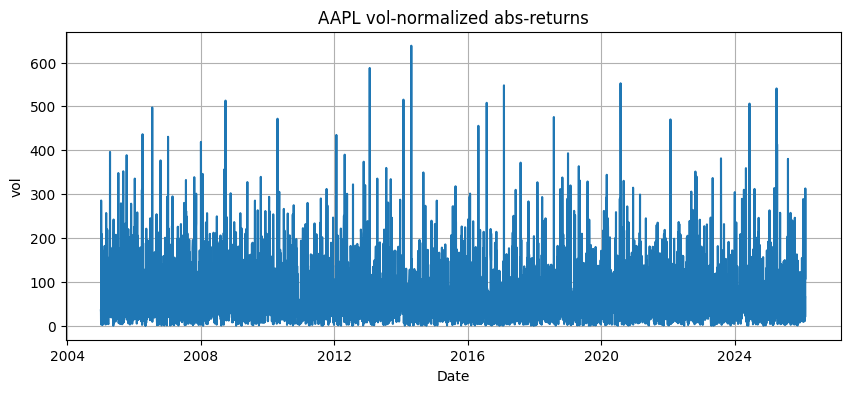

In [107]:
# vol-normalized returns

z = r/sigma
z_abs = np.abs(z)

plt.figure(figsize = (10, 4))
plt.plot(z)
plt.title(f"{ticker} vol-normalized returns")
plt.xlabel("Date")
plt.ylabel("vol")
plt.grid(True)
plt.show()

plt.figure(figsize = (10, 4))
plt.plot(z_abs)
plt.title(f"{ticker} vol-normalized abs-returns")
plt.xlabel("Date")
plt.ylabel("vol")
plt.grid(True)
plt.show()

<Figure size 640x480 with 0 Axes>

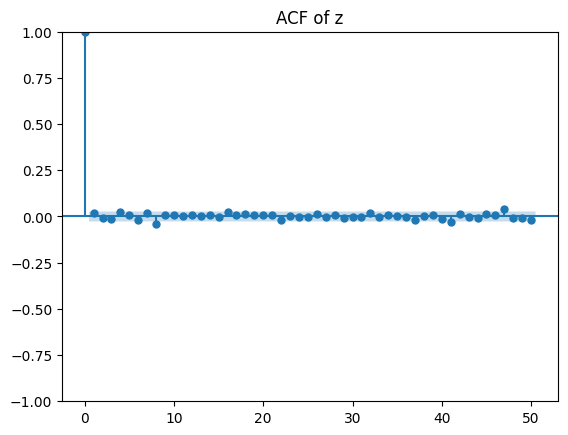

<Figure size 640x480 with 0 Axes>

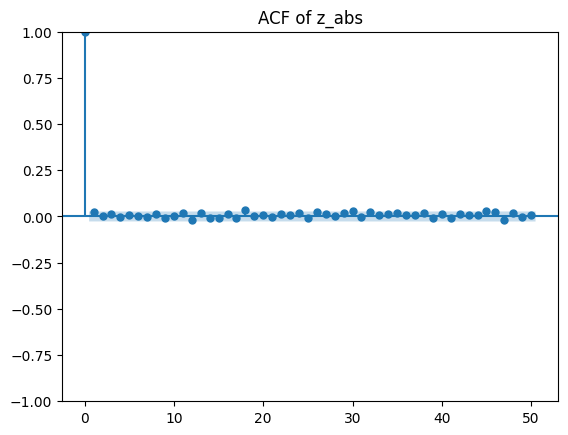

<Figure size 640x480 with 0 Axes>

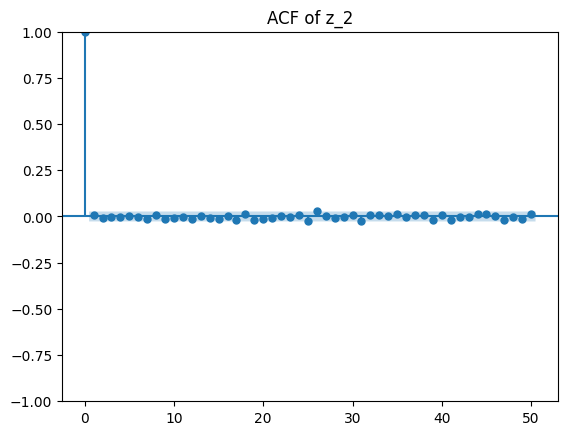

In [109]:
plt.figure()
plot_acf(z, lags=50)
plt.title("ACF of z")
plt.show()

plt.figure()
plot_acf(z_abs, lags=50)
plt.title("ACF of z_abs")
plt.show()

plt.figure()
plot_acf(np.pow(z, 2), lags=50)
plt.title("ACF of z_2")
plt.show()


In [ ]:
# Ljung-Box on z and z_abs

ljung_box_plot(z, max_lag=50, title="Ljung–Box on z")
ljung_box_plot(z_abs, max_lag=50, title="Ljung–Box on z_abs")
ljung_box_plot(np.pow(z, 2), max_lag=50, title="Ljung–Box on z^2")

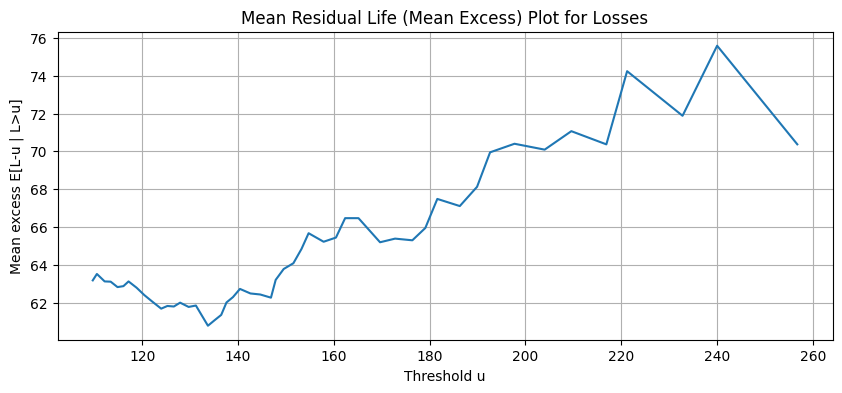

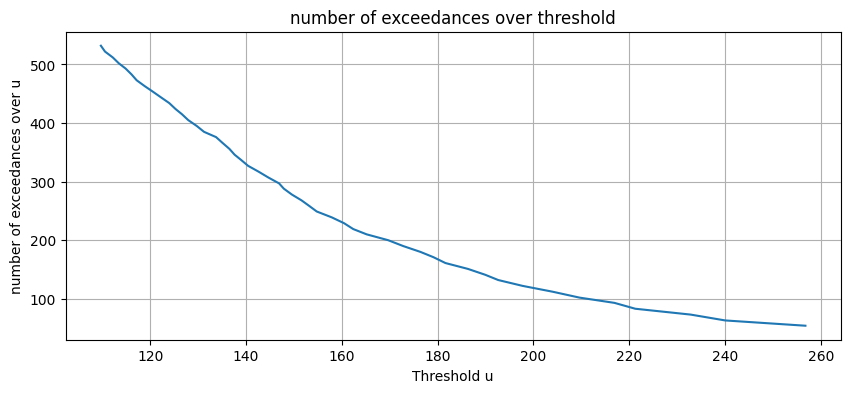

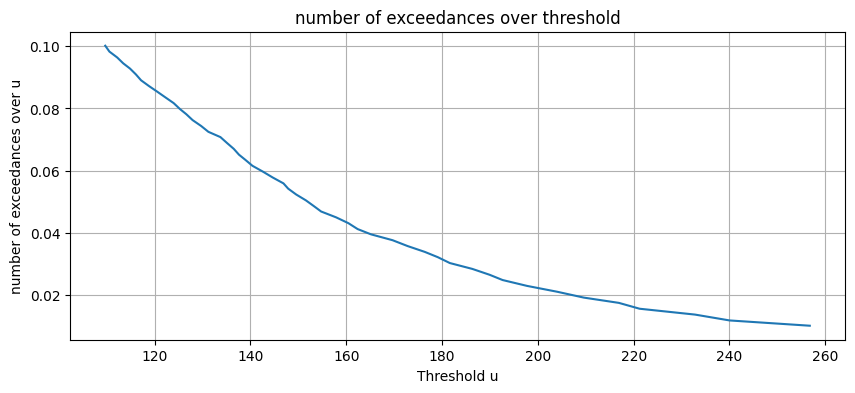

In [167]:
# Mean residual life plot

L = (-z).dropna()

def mean_excess_plot(x, u_grid):
    x = np.asarray(x)
    me = []
    exceedances = []
    for u in u_grid:
        exc = x[x > u] - u
        exceedances.append(len(exc))
        me.append(np.nan if len(exc)==0 else exc.mean())
    return np.array(me), np.array(exceedances)

u_grid = np.quantile(L, np.linspace(0.90, 0.99, 50))
# u_grid = np.linspace(np.quantile(L, 0.9), np.quantile(L, 0.9975), 250)


me, num = mean_excess_plot(L, u_grid)

plt.figure(figsize=(10,4))
plt.plot(u_grid, me)
plt.title("Mean Residual Life (Mean Excess) Plot for Losses")
plt.xlabel("Threshold u")
plt.ylabel("Mean excess E[L-u | L>u]")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
# plt.plot(u_grid, num/len(L))
plt.plot(u_grid, num)
plt.title("number of exceedances over threshold")
plt.xlabel("Threshold u")
plt.ylabel("number of exceedances over u")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(u_grid, num/len(L))
# plt.plot(u_grid, num)
plt.title("number of exceedances over threshold")
plt.xlabel("Threshold u")
plt.ylabel("number of exceedances over u")
plt.grid(True)
plt.show()


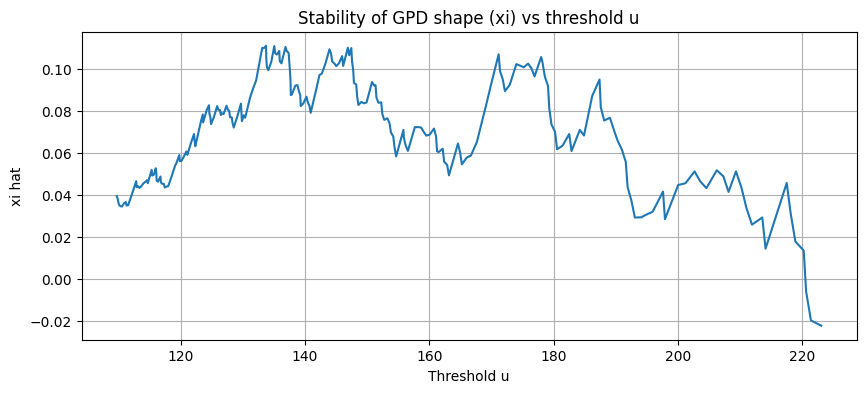

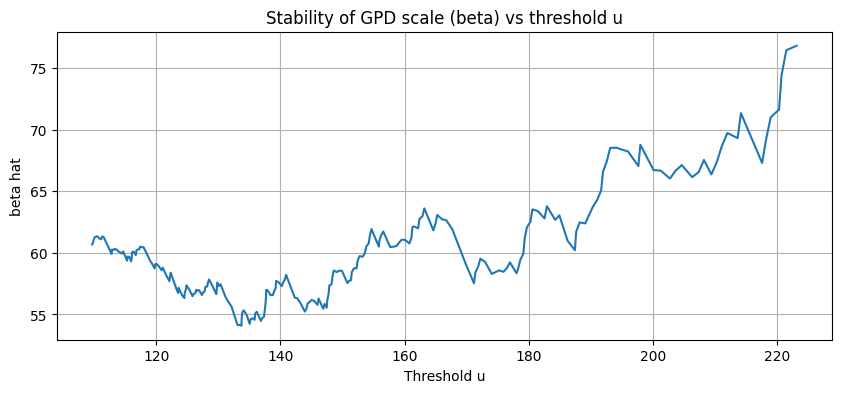

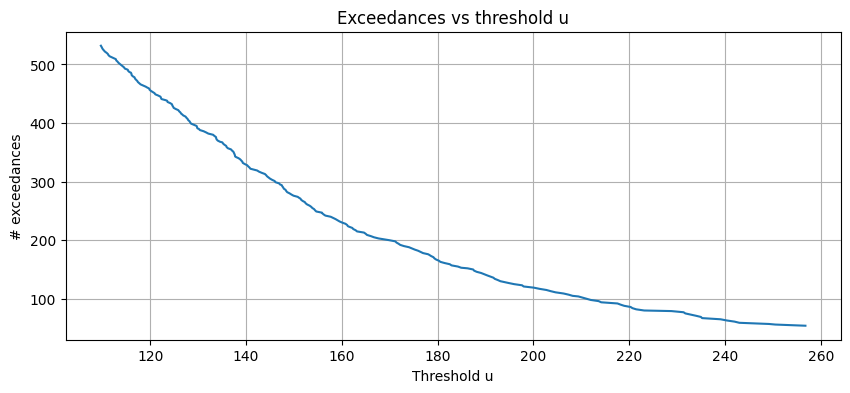

In [177]:
from scipy.stats import genpareto

L = (-z).dropna()
u_grid = np.quantile(L, np.linspace(0.90, 0.99, 250))

xis, betas, nums = [], [], []

for u in u_grid:
    exc = L[L > u] - u
    nums.append(len(exc))
    if len(exc) < 80:
        xis.append(np.nan); betas.append(np.nan)
        continue
    xi, loc, beta = genpareto.fit(exc, floc=0)
    xis.append(xi); betas.append(beta)


plt.figure(figsize=(10,4))
plt.plot(u_grid, xis)
plt.title("Stability of GPD shape (xi) vs threshold u")
plt.xlabel("Threshold u")
plt.ylabel("xi hat")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(u_grid, betas)
plt.title("Stability of GPD scale (beta) vs threshold u")
plt.xlabel("Threshold u")
plt.ylabel("beta hat")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(u_grid, nums)
plt.title("Exceedances vs threshold u")
plt.xlabel("Threshold u")
plt.ylabel("# exceedances")
plt.grid(True)
plt.show()


In [ ]:
# QQ-plots

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genpareto

def gpd_qq(exc, xi, beta, title="GPD QQ"):
    exc_sorted = np.sort(exc)
    n = len(exc_sorted)
    p = (np.arange(1, n+1) - 0.5) / n
    theo = genpareto.ppf(p, c=xi, loc=0, scale=beta)

    plt.figure(figsize=(5,5))
    plt.plot(theo, exc_sorted, marker=".", linestyle="none")
    m = max(theo.max(), exc_sorted.max())
    plt.plot([0, m], [0, m])  # 45-degree line
    plt.title(title)
    plt.xlabel("Theoretical GPD quantiles")
    plt.ylabel("Empirical exceedances")
    plt.grid(True)
    plt.show()


